In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score

import matplotlib.pyplot as plt

In [2]:
import pandas as pd
df = pd.read_csv("../data/processed/airbnb_cleaned.csv")

print(df.shape)
df.head()

(48392, 20)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_per_review,is_private_room,is_entire_home,has_reviews
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,14.900000,1,0,1
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,4.891304,0,1,1
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,No Review,0.00,1,365,150.000000,1,0,0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,0.328413,0,1,1
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,8.000000,0,1,1


In [3]:
print(df.shape)
print(df.columns.tolist())

(48392, 20)
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'price_per_review', 'is_private_room', 'is_entire_home', 'has_reviews']


In [4]:
print(df.columns.tolist())

['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'price_per_review', 'is_private_room', 'is_entire_home', 'has_reviews']


In [5]:
features = [
    'neighbourhood_group',
    'neighbourhood',
    'room_type',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'is_private_room',
    'is_entire_home',
    'has_reviews'
]

X = df[features]
y = df['price']

print(X.shape)

(48392, 11)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(38713, 11)
(9679, 11)


In [8]:
categorical_features = [
    'neighbourhood_group',
    'neighbourhood',
    'room_type'
]

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(38713, 11)
(9679, 11)


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

_ = lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully")

Linear Regression model trained successfully


In [12]:
lr_predictions = lr_model.predict(X_test)

print("Predictions generated")

Predictions generated


In [19]:
from sklearn.metrics import mean_absolute_error, r2_score

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("MAE:", round(lr_mae, 2))
print("R²:", round(lr_r2, 4))

Linear Regression Results
MAE: 50.14
R²: 0.4106


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest pipeline created")

Random Forest pipeline created


In [16]:
_ = rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [17]:
rf_predictions = rf_model.predict(X_test)

print("Predictions generated")

Predictions generated


In [20]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE:", round(rf_mae, 2))
print("R²:", round(rf_r2, 4))

Random Forest Results
MAE: 47.08
R²: 0.4603


In [21]:
X.columns.tolist()

['neighbourhood_group',
 'neighbourhood',
 'room_type',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'is_private_room',
 'is_entire_home',
 'has_reviews']

In [26]:
df[['price', 'price_per_review']].head(10)

,price,price_per_review
0,149,14.900000
1,225,4.891304
2,150,150.000000
3,89,0.328413
4,80,8.000000
5,200,2.666667
6,60,1.200000
7,79,0.183295
8,79,0.663866
9,150,0.931677


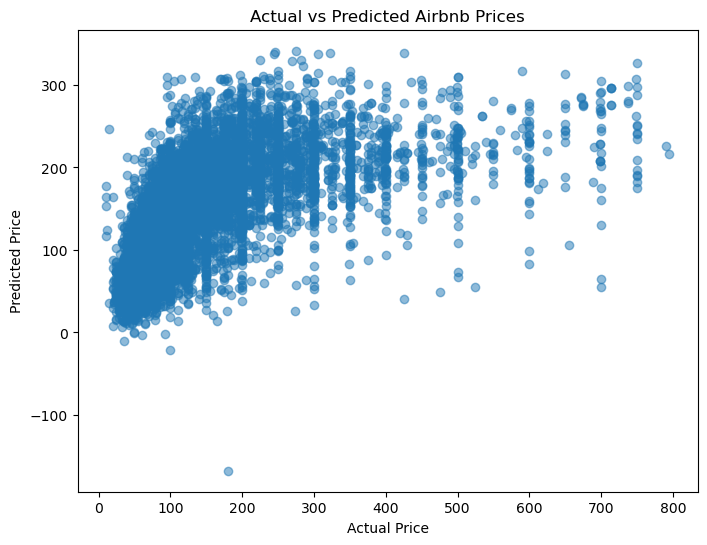

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lr_predictions,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices")

plt.show()

In [22]:
results = X_test.copy()

results["actual_price"] = y_test.values
results["predicted_price"] = lr_predictions

results["price_gap"] = (
    results["predicted_price"]
    - results["actual_price"]
)

In [23]:
underpriced = results.sort_values(
    by="price_gap",
    ascending=False
)

underpriced.head(20)

,neighbourhood_group,neighbourhood,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,is_private_room,is_entire_home,has_reviews,actual_price,predicted_price,price_gap
47486,Manhattan,Hell's Kitchen,Entire home/apt,2,0,0.00,1,139,0,1,0,15,246.233242,231.233242
17192,Manhattan,Tribeca,Entire home/apt,7,0,0.00,1,0,0,1,0,95,309.505477,214.505477
19378,Manhattan,Midtown,Entire home/apt,30,0,0.00,52,297,0,1,0,95,299.726559,204.726559
40484,Manhattan,Midtown,Entire home/apt,30,0,0.00,4,339,0,1,0,105,304.346720,199.346720
40689,Manhattan,Midtown,Entire home/apt,30,0,0.00,4,362,0,1,0,115,306.970964,191.970964
16900,Manhattan,Midtown,Entire home/apt,30,5,0.23,52,342,0,1,1,95,284.808274,189.808274
11153,Manhattan,Midtown,Entire home/apt,30,2,0.05,52,365,0,1,1,100,287.580502,187.580502
28423,Manhattan,Tribeca,Entire home/apt,7,0,0.00,1,0,0,1,0,135,309.505477,174.505477
2158,Brooklyn,Williamsburg,Entire home/apt,15,10,0.13,3,365,0,1,1,40,212.360105,172.360105
11521,Manhattan,Midtown,Entire home/apt,6,0,0.00,1,0,0,1,0,103,273.937126,170.937126
